#   Explore Data Analysis
##  Table of Contents
1. [Environment Setup](#1)
2. [Making Class for analysis](#2)
3. [Load and inspect data](#3)
4. [Data Quality Assessment](#4)
5. [Univariate Analysis](#5)
6. [Bivariate Analysis](#6)
7. [Correlation Analysis](#7)


<a id='1'></a>
### 1. Environment setup 


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

<a id='2'></a>
### 2. Making Class for analysis
This class performs the full EDA pipeline, including data loading, data quality checks, descriptive analysis, and visualization. Each step is separated into methods to make the code modular, easy to understand, and reusable.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display


class DiabetesEDA:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

        # Optional custom colors
        self.CYAN = "#00E5FF"
        self.PINK = "#FF4081"
        self.BG = "#0D0F1A"

    def load_data(self):
        # Load the dataset and do basic cleaning of column names.
        self.df = pd.read_csv(self.file_path)
        self.df.columns = [
            col.strip().lower().replace(" ", "_") for col in self.df.columns
        ]
        print("Data loaded successfully.")
        return self.df

    def check_data_loaded(self):
        # Helper method to ensure data is loaded before any analysis.
        if self.df is None:
            raise ValueError("Data is not loaded yet. Please run load_data() first.")

    def preview_data(self, n=5):
        #Show the first n rows of the dataset.
        self.check_data_loaded()
        return self.df.head(n)

    def dataset_shape(self):

        # Print the number of rows and columns in the dataset.
        self.check_data_loaded()
        print(f"Shape: {self.df.shape}")

    def data_info(self):
        # print summary info about the dataset, including data types and non-null counts.
        self.check_data_loaded()
        print("Dataset Info:")
        self.df.info()

    def describe_data(self):
        # Show summary statistics for numeric and categorical columns.
        self.check_data_loaded()
        return self.df.describe(include="all").T

    def check_missing_values(self):
        # Count and print the number of missing values in each column.
        self.check_data_loaded()
        missing = self.df.isnull().sum()
        print("Missing values per column:")
        if missing.sum() == 0:
            print("No missing values found.")
        else:
            print(missing[missing > 0])

    def check_duplicates(self):
        # Count and print the number of duplicate rows in the dataset.
        self.check_data_loaded()
        dups = self.df.duplicated().sum()
        print(f"Duplicate rows: {dups}")

    def unique_values(self):
        # Print the number of unique values in each column.
        self.check_data_loaded()
        print("Unique values per column:")
        print(self.df.nunique())

    def class_distribution_summary(self, target="class"):
        """
        Print class distribution and a quick imbalance check.
        Assumes:
        0 = Non-diabetic
        1 = Diabetic
        """
        self.check_data_loaded()

        counts = self.df[target].value_counts()
        print("Class distribution:")

        for k, v in counts.items():
            label = "Positive (Diabetic)" if k == 1 else "Negative (Non-diabetic)"
            print(f"Class {k} ({label}): {v} ({(v / len(self.df)) * 100:.2f}%)")

        if len(counts) == 2:
            ratio = counts.min() / counts.max()
            print(f"\nImbalance ratio: {ratio:.2f}")

            if ratio < 0.5:
                print("Significant imbalance detected.")
            else:
                print("Class balance is acceptable.")

    def get_symptom_columns(self):
        # Helper method to identify symptom columns based on naming convention.
        self.check_data_loaded()
        exclude = {"age", "gender", "class"}
        return [col for col in self.df.columns if col not in exclude]

    def plot_class_distribution(self, target="class"):
       
        self.check_data_loaded()
        plt.figure(figsize=(6, 4))
        sns.countplot(data=self.df, x=target , hue=target, palette=[self.PINK, self.CYAN], legend=False )
        plt.title("Class Distribution")
        plt.xlabel("Class (0 = Non-diabetic, 1 = Diabetic)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    def plot_age_distribution(self):
        
        self.check_data_loaded()

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle("Age Distribution Analysis", y=1.03)

        # Histogram for age by class
        for key, val in self.df.groupby("class"):
            label = "Positive (Diabetic)" if key == 1 else "Negative (Non-diabetic)"
            color = self.CYAN if key == 1 else self.PINK
            sns.histplot(
                val["age"],
                bins=20,
                ax=axes[0],
                label=label,
                color=color,
                alpha=0.6
            )

        axes[0].set_title("Age Distribution by Class")
        axes[0].set_xlabel("Age")
        axes[0].set_ylabel("Count")
        axes[0].legend()

        # Box plot for age by class
        sns.boxplot(data=self.df, x="class", y="age", ax=axes[1], hue="class", palette=[self.PINK, self.CYAN], legend=False)
        axes[1].set_title("Age Box Plot by Class")
        axes[1].set_xlabel("Class")
        axes[1].set_ylabel("Age")

        plt.tight_layout()
        plt.show()

        print("\nAge statistics by class:")
        print(self.df.groupby("class")["age"].describe().round(1))

    def plot_symptom_prevalence(self):
       
        self.check_data_loaded()

        symptom_cols = self.get_symptom_columns()
        symptom_counts = self.df[symptom_cols].sum().sort_values(ascending=False)

        print("Symptom prevalence:")
        for symptom, count in symptom_counts.items():
            print(f"{symptom}: {count} ({(count / len(self.df)) * 100:.1f}%)")

        plt.figure(figsize=(12, 5))
        sns.barplot(x=symptom_counts.index, y=symptom_counts.values)
        plt.title("Symptom Prevalence in Dataset")
        plt.xlabel("Symptom")
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    def plot_symptom_by_class(self):
        
        self.check_data_loaded()

        symptom_cols = self.get_symptom_columns()

        plot_df = self.df.groupby("class")[symptom_cols].mean().T
        plot_df.columns = ["Negative (Non-diabetic)", "Positive (Diabetic)"]
        plot_df = plot_df.sort_values("Positive (Diabetic)", ascending=False).reset_index()
        plot_df = plot_df.melt(id_vars="index", var_name="Class", value_name="Prevalence")
        plot_df = plot_df.rename(columns={"index": "Symptom"})

        plt.figure(figsize=(12, 6))
        sns.barplot(data=plot_df, x="Symptom", y="Prevalence", hue="Class")
        plt.title("Symptom Prevalence by Class")
        plt.xlabel("Symptom")
        plt.ylabel("Mean Prevalence")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    def plot_gender_analysis(self):
        
        self.check_data_loaded()

        plot_data = self.df.copy()
        plot_data["gender"] = plot_data["gender"].map({0: "Female", 1: "Male"})
        plot_data["class"] = plot_data["class"].map({0: "Negative", 1: "Positive"})

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle("Gender Analysis", y=1.03)

        sns.countplot(data=plot_data, x="gender", hue="class", ax=axes[0])
        axes[0].set_title("Class Count by Gender")
        axes[0].set_xlabel("Gender")
        axes[0].set_ylabel("Count")

        ct = pd.crosstab(plot_data["gender"], plot_data["class"], normalize="index") * 100
        ct.plot(kind="bar", stacked=True, ax=axes[1])
        axes[1].set_title("Class Proportion by Gender")
        axes[1].set_xlabel("Gender")
        axes[1].set_ylabel("Percentage")

        plt.tight_layout()
        plt.show()

    def plot_age_violin(self):
        
        self.check_data_loaded()

        plt.figure(figsize=(8, 5))
        sns.violinplot(data=self.df, x="class", y="age", hue="class", palette=[self.PINK, self.CYAN], legend=False)
        plt.title("Age Distribution by Class")
        plt.xlabel("Class")
        plt.ylabel("Age")
        plt.xticks([0, 1], ["Negative (0)", "Positive (1)"])
        plt.tight_layout()
        plt.show()

    def plot_feature_correlation_with_target(self, target="class"):
       
        self.check_data_loaded()

        corr = self.df.corr(numeric_only=True)[target].drop(target).sort_values()

        plt.figure(figsize=(8, 5))
        corr.plot(kind="barh")
        plt.title("Feature Correlation with Diabetes")
        plt.xlabel("Correlation")
        plt.tight_layout()
        plt.show()

    def plot_correlation_heatmap(self):
        
        self.check_data_loaded()

        corr = self.df.corr(numeric_only=True)

        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Correlation Matrix")
        plt.tight_layout()
        plt.show()

    def run_data_quality_report(self):
        """Run the main data quality checks."""
        self.check_data_loaded()

        self.dataset_shape()
        self.check_missing_values()
        self.check_duplicates()
        self.unique_values()
        self.class_distribution_summary()

<a id='3'></a>
# 3. Load and inspect data

In [61]:
analysis = DiabetesEDA("../data/clean_diabetes.csv")
analysis.load_data()
analysis.check_data_loaded()

Data loaded successfully.


In [62]:
analysis.dataset_shape()
print("\nPreview:")
analysis.preview_data()

Shape: (251, 17)

Preview:


,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [50]:
print("\nSummary statistics:")
analysis.describe_data()


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
age,251.0,48.864542,12.526036,16.0,39.0,48.0,58.0,90.0
gender,251.0,0.637450,0.481697,0.0,0.0,1.0,1.0,1.0
polyuria,251.0,0.525896,0.500327,0.0,0.0,1.0,1.0,1.0
polydipsia,251.0,0.494024,0.500963,0.0,0.0,0.0,1.0,1.0
sudden_weight_loss,251.0,0.414343,0.493592,0.0,0.0,0.0,1.0,1.0
weakness,251.0,0.633466,0.482820,0.0,0.0,1.0,1.0,1.0
polyphagia,251.0,0.466135,0.499849,0.0,0.0,0.0,1.0,1.0
genital_thrush,251.0,0.266932,0.443241,0.0,0.0,0.0,1.0,1.0
visual_blurring,251.0,0.442231,0.497644,0.0,0.0,0.0,1.0,1.0
itching,251.0,0.505976,0.500963,0.0,0.0,1.0,1.0,1.0


<a id='4'></a>
# 4. Data Quality Assessment

In [51]:
analysis.run_data_quality_report()

Shape: (251, 17)
Missing values per column:
No missing values found.
Duplicate rows: 0
Unique values per column:
age                   51
gender                 2
polyuria               2
polydipsia             2
sudden_weight_loss     2
weakness               2
polyphagia             2
genital_thrush         2
visual_blurring        2
itching                2
irritability           2
delayed_healing        2
partial_paresis        2
muscle_stiffness       2
alopecia               2
obesity                2
class                  2
dtype: int64
Class distribution:
Class 1 (Positive (Diabetic)): 173 (68.92%)
Class 0 (Negative (Non-diabetic)): 78 (31.08%)

Imbalance ratio: 0.45
Significant imbalance detected.


<a id='5'></a>
# 5.Univariate analysis

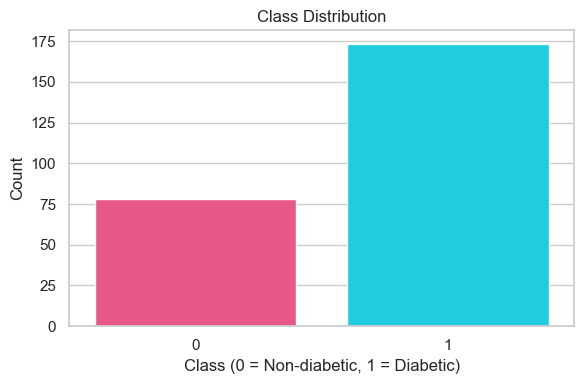

'Plot how many positive and negative cases exist.'

In [86]:
analysis.plot_class_distribution()
"""Plot how many positive and negative cases exist."""

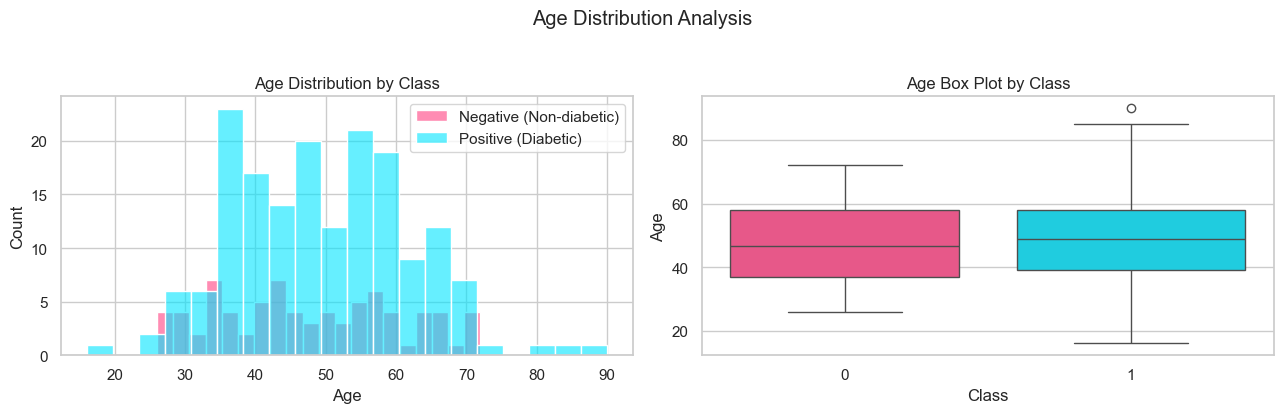


Age statistics by class:
       count  mean   std   min   25%   50%   75%   max
class                                                 
0       78.0  47.9  12.8  26.0  37.0  46.5  58.0  72.0
1      173.0  49.3  12.4  16.0  39.0  49.0  58.0  90.0


'\n        Show age distribution using:\n        1. Histogram by class\n        2. Box plot by class\n'

In [85]:
analysis.plot_age_distribution()
"""
        Show age distribution using:
        1. Histogram by class
        2. Box plot by class
"""

Symptom prevalence:
weakness: 159 (63.3%)
polyuria: 132 (52.6%)
itching: 127 (50.6%)
delayed_healing: 125 (49.8%)
polydipsia: 124 (49.4%)
polyphagia: 117 (46.6%)
partial_paresis: 112 (44.6%)
visual_blurring: 111 (44.2%)
sudden_weight_loss: 104 (41.4%)
muscle_stiffness: 98 (39.0%)
alopecia: 90 (35.9%)
irritability: 71 (28.3%)
genital_thrush: 67 (26.7%)
obesity: 44 (17.5%)


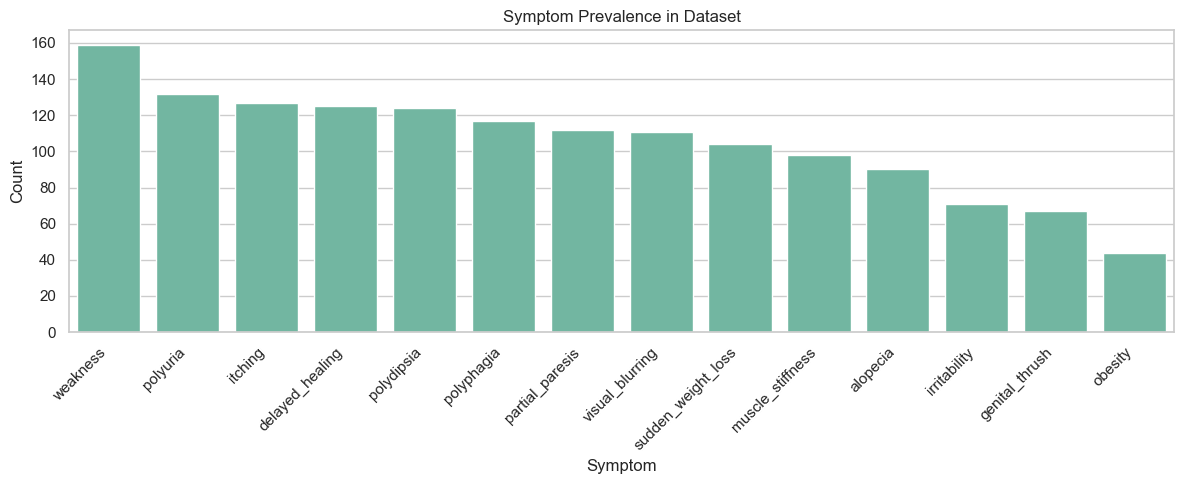

'\n        Show how common each symptom is in the full dataset.\n        Assumes symptom columns are binary (0/1).\n'

In [65]:
analysis.plot_symptom_prevalence()
"""
        Show how common each symptom is in the full dataset.
        Assumes symptom columns are binary (0/1).
"""

<a id='6'></a>
# 6.Bivariate analysis

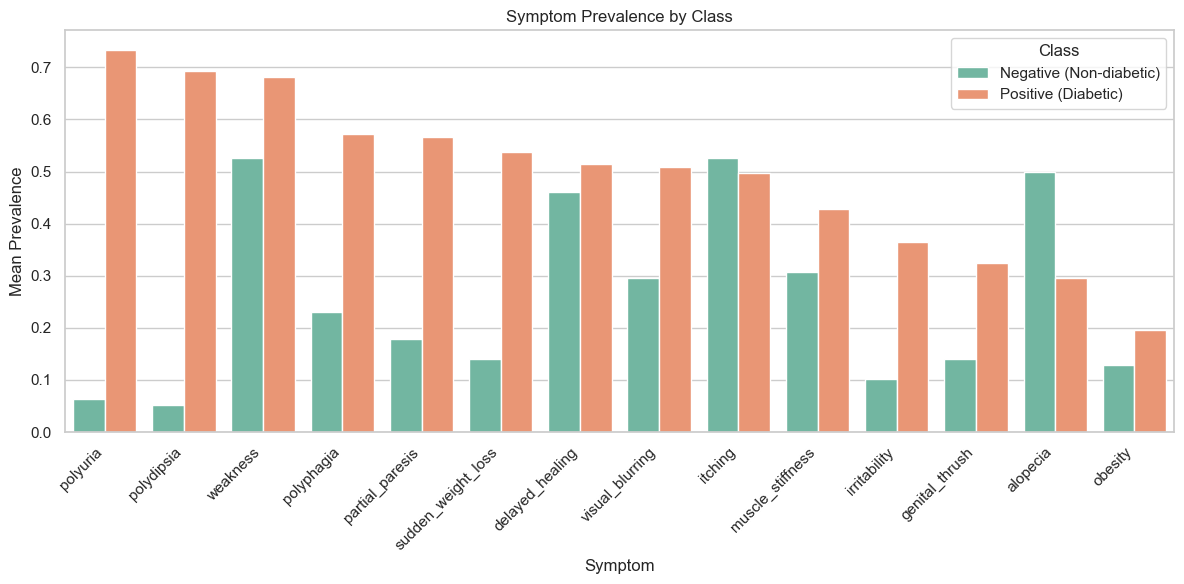

'\n        Compare symptom prevalence between diabetic and non-diabetic groups.\n'

In [66]:
analysis.plot_symptom_by_class()
"""
        Compare symptom prevalence between diabetic and non-diabetic groups.
"""

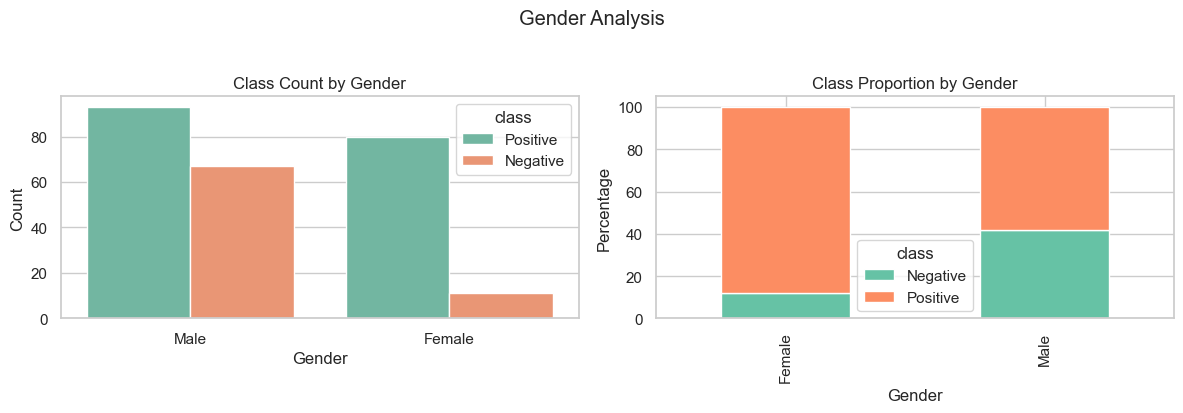

'\n        Explore how class is distributed across gender.\n        Left plot: counts\n        Right plot: proportions\n'

In [67]:
analysis.plot_gender_analysis()
"""
        Explore how class is distributed across gender.
        Left plot: counts
        Right plot: proportions
"""

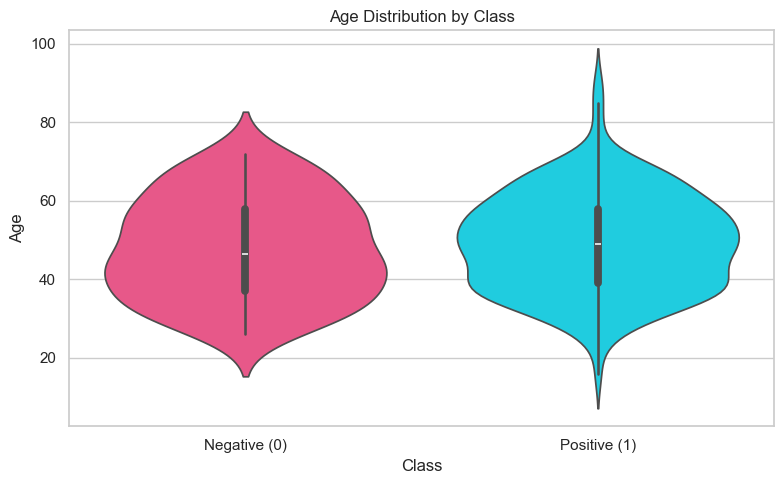

In [ ]:
analysis.plot_age_violin()
"""Use a violin plot to show age spread by class."""

<a id='7'></a>
# 7. Correlation analysis

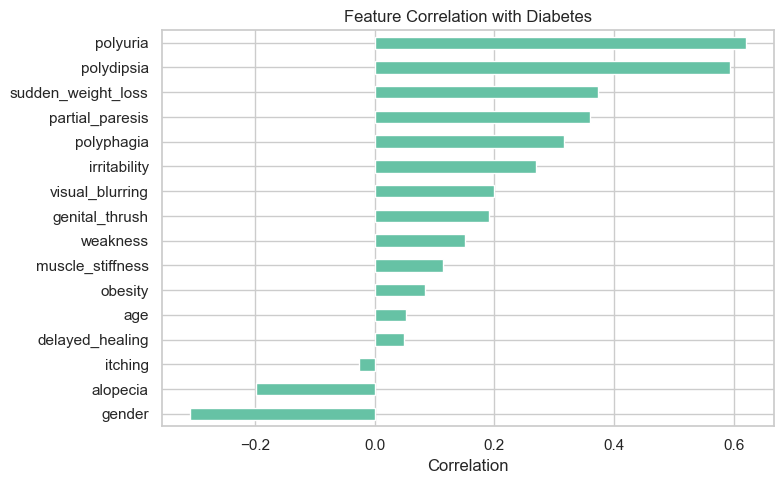

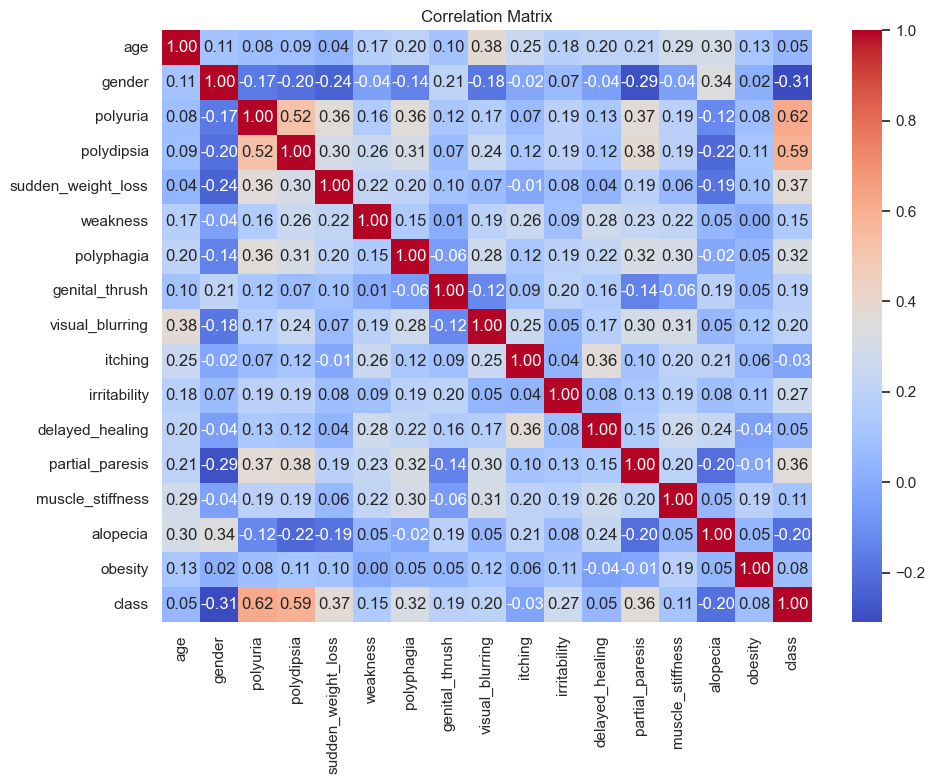

'Show a full correlation heatmap for numeric columns.'

In [68]:
analysis.plot_feature_correlation_with_target()
"""
        Show correlation of each numeric feature with the target column.
        Useful for a quick relationship check.
"""
analysis.plot_correlation_heatmap()
"""Show a full correlation heatmap for numeric columns."""